<a href="https://colab.research.google.com/github/Lattemelia/Portforio/blob/main/Logistics_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

近年の物流業界は、労働規制の強化（2024年問題）や燃料コストの高騰、さらにはドライバー不足の深刻化に伴い、従来の「稼働時間や走行距離を増やして売上を伸ばす」という規模拡大型の経営モデルからの脱却を迫られている。

特に、実車効率の低下や「帰り便（復路）」「隙間時間」における運賃の買い叩きは、部門全体の利益率を著しく圧迫する要因となっている。本プロジェクトは、限られたリソース（車両・人員・時間）を増やすことなく、営業利益を確実に10%底上げし、高収益かつ持続可能な運輸部門へと体質改善することを目的とする。



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as nd
import seaborn as sns

PATH="/content/drive/MyDrive/Colab Notebooks/Logistics"
delivery_events = pd.read_csv(PATH + "/delivery_events.csv")
loads = pd.read_csv(PATH + "/loads.csv")
trips = pd.read_csv(PATH + "/trips.csv")
routes = pd.read_csv(PATH + "/routes.csv")


In [3]:
events_cols = ['load_id', 'trip_id', 'event_type', 'facility_id','actual_datetime', 'detention_minutes',
       'on_time_flag', 'location_city']
loads_cols = ["load_id", "route_id", "revenue", "fuel_surcharge", "accessorial_charges"]
trips_cols = ["trip_id","actual_distance_miles", "fuel_gallons_used", "actual_duration_hours", "idle_time_hours"]
routes_cols = ["route_id", "origin_city", "destination_city"]

loads_and_trips = delivery_events[events_cols].merge(loads[loads_cols], on="load_id", how="inner")
loads_and_trips = loads_and_trips.merge(trips[trips_cols], on="trip_id", how="inner")
base_table = loads_and_trips.merge(routes[routes_cols], on="route_id", how="inner")

print(base_table.columns)

Index(['load_id', 'trip_id', 'event_type', 'facility_id', 'actual_datetime',
       'detention_minutes', 'on_time_flag', 'location_city', 'route_id',
       'revenue', 'fuel_surcharge', 'accessorial_charges',
       'actual_distance_miles', 'fuel_gallons_used', 'actual_duration_hours',
       'idle_time_hours', 'origin_city', 'destination_city'],
      dtype='object')


In [5]:
# 1列ずつ個別に datetime 型に変換して上書きする
base_table["actual_datetime"] = pd.to_datetime(base_table["actual_datetime"])

base_table["actual_datetime"] = base_table["actual_datetime"].dt.date

利益率の高いコース・低いコースを算出

In [4]:
from os import rename
#燃料費算出と結合
#燃料費を道ごとにサマリ
fuel_price = pd.read_csv(PATH + "/fuel_purchases.csv")
fuel_cost = fuel_price.groupby("trip_id")["total_cost"].sum().reset_index()
#わかりやすくカラム名を変更
fuel_cost.rename(columns={"total_cost": "total_fuel_cost"}, inplace=True)
#燃料費用をベーステーブルへ結合
fuel_col = ["trip_id", "total_fuel_cost"]
base_table = base_table.merge(fuel_cost[fuel_col],on="trip_id",how="inner")


In [6]:
base_table

,load_id,trip_id,event_type,facility_id,actual_datetime,detention_minutes,on_time_flag,location_city,route_id,revenue,fuel_surcharge,accessorial_charges,actual_distance_miles,fuel_gallons_used,actual_duration_hours,idle_time_hours,origin_city,destination_city,total_fuel_cost
0,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01,0,False,Houston,RTE00019,3045.23,406.72,100,1314,183.8,26.2,3.5,Houston,Detroit,779.45
1,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02,230,True,Detroit,RTE00019,3045.23,406.72,100,1314,183.8,26.2,3.5,Houston,Detroit,779.45
2,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01,62,True,Kansas City,RTE00058,1224.48,98.61,0,515,93.6,8.6,8.3,Kansas City,Indianapolis,752.70
3,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02,67,False,Indianapolis,RTE00058,1224.48,98.61,0,515,93.6,8.6,8.3,Kansas City,Indianapolis,752.70
4,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01,83,True,Columbus,RTE00048,7171.12,792.88,0,2509,339.1,45.0,12.0,Columbus,Portland,3796.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153873,LOAD00085408,TRIP00085408,Delivery,FAC00045,2025-01-01,126,False,Portland,RTE00056,3952.46,309.24,200,1722,243.6,28.2,8.7,Kansas City,Portland,1196.20
153874,LOAD00085409,TRIP00085409,Pickup,FAC00025,2024-12-31,13,False,Philadelphia,RTE00016,6296.47,463.93,75,2758,415.4,47.9,4.8,Philadelphia,Seattle,1426.09
153875,LOAD00085409,TRIP00085409,Delivery,FAC00001,2025-01-02,81,False,Seattle,RTE00016,6296.47,463.93,75,2758,415.4,47.9,4.8,Philadelphia,Seattle,1426.09
153876,LOAD00085410,TRIP00085410,Pickup,FAC00027,2024-12-31,48,True,Dallas,RTE00007,4350.65,504.32,75,1616,237.0,26.0,4.8,Dallas,New York,511.16


In [7]:
#総売り上げ(revenue)を算出
base_table["total_revenue"] = (
    base_table["revenue"]
    + base_table["fuel_surcharge"]
    + base_table["accessorial_charges"]
)

#燃費算出
base_table["fuel_per_mile"] = (
    base_table["fuel_gallons_used"]
    / base_table["actual_distance_miles"]
)

#総売り上げ(revenue)-燃料費(total_fuel_cost)で利益(profit)の算出
base_table["profit"] = base_table["total_revenue"] - base_table['total_fuel_cost']

#利益(profit)がプラスならTrueを返すフラグ
base_table['profitability'] = base_table['profit']<0


In [8]:
#道ごとの平均・合計をサマリ
route_summary = base_table.groupby(by='route_id').agg({
    "profit": 'mean',
    'profitability':'mean',
    'fuel_per_mile' : 'mean',
    'actual_duration_hours': 'mean',
    'trip_id':'count'
    })
#カラム名をわかりやすく変更
route_summary = route_summary.rename(columns={
    "profit": "avg_profit",
    'profitability':'pct_unprofitable',
    'fuel_per_mile' : 'avg_fuel_per_mile',
    'actual_duration_hours': 'avg_duration',
    'trip_id':'total_trips'})

#コースの赤字割合(pct_unprofitable)を算出
route_summary['pct_unprofitable'] = route_summary['pct_unprofitable'] *100

#コースの赤字割合が高いコースから降順に並び替え
route_summary= route_summary.sort_values('pct_unprofitable', ascending = False)

#1時間当たりの利益(profit_per_hour)を算出
route_summary["profit_per_hour"] = route_summary["avg_profit"] / route_summary["avg_duration"]

#赤字コース(全6コース)をを表示
print(route_summary[['avg_profit','profit_per_hour']].head(6).reset_index())

   route_id   avg_profit  profit_per_hour
0  RTE00010 -1000.748462      -606.958084
1  RTE00015  -949.438298      -575.808831
2  RTE00033  -720.136257      -240.456915
3  RTE00036  -389.394173       -82.742509
4  RTE00047  -110.320007       -12.901148
5  RTE00011  -112.906603       -11.486024


算出した回帰曲線式: y = 148.33 * ln(x) + -398.33
決定係数 (R2): 0.7273


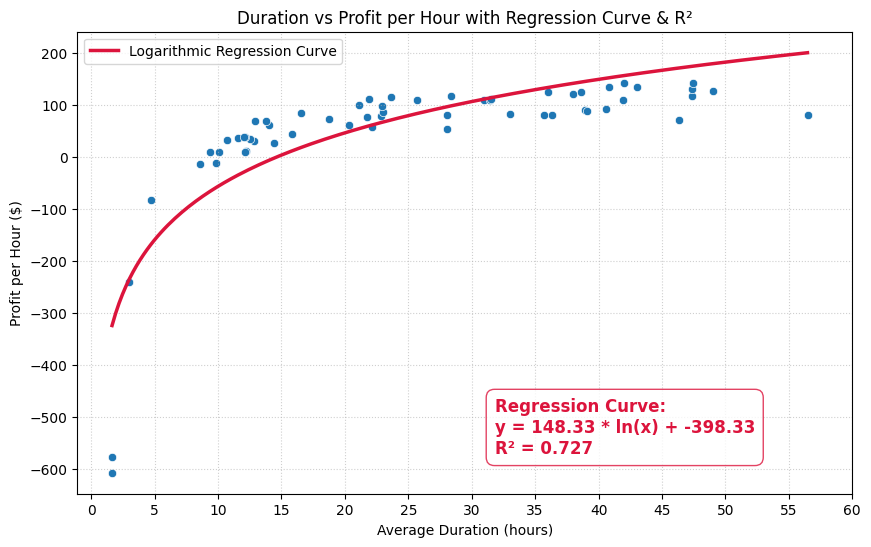

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score  # 🔥 決定係数を計算するライブラリ

plt.figure(figsize=(10, 6))

#散布図を描画
sns.scatterplot(
    data=route_summary,
    x="avg_duration",
    y="profit_per_hour"
)

#対数回帰曲線の計算
x_data = route_summary["avg_duration"]
y_data = route_summary["profit_per_hour"]

# xを対数（log）に変換して1次フィットさせ、係数を算出
a, b = np.polyfit(np.log(x_data), y_data, 1)

#全データの「対数モデルによる予測値（yの理論値）」を計算
y_pred = a * np.log(x_data) + b

#実績値（y_data）と予測値（y_pred）から決定係数（R2）を算出
r2 = r2_score(y_data, y_pred)

#数式とR2スコアをテキスト用にフォーマット
curve_equation = f"y = {a:.2f} * ln(x) + {b:.2f}"
r2_text = f"R² = {r2:.3f}"  # 小数点以下3桁で表示
print(f"算出した回帰曲線式: {curve_equation}")
print(f"決定係数 (R2): {r2:.4f}")

#曲線を描くための滑らかなX軸のデータを作成してプロット
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_smooth = a * np.log(x_smooth) + b

plt.plot(
    x_smooth, y_smooth,
    color="crimson",
    linewidth=2.5,
    label="Logarithmic Regression Curve"
)

#グラフ内に「回帰曲線の数式」と「決定係数（R2）」を合わせて表示
x_pos = x_data.max() - ((x_data.max() - x_data.min()) * 0.45)
y_pos = y_data.min() + ((y_data.max() - y_data.min()) * 0.05)

plt.text(
    x_pos, y_pos,
    f"Regression Curve:\n{curve_equation}\n{r2_text}",
    fontsize=12,
    color="crimson",
    weight="bold",
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='crimson', boxstyle='round,pad=0.5')
)

# x軸の目盛りを5刻みに設定
x_max = x_data.max()
plt.xticks(np.arange(0, x_max + 5, 5))

#タイトルと仕上げ
plt.title("Duration vs Profit per Hour with Regression Curve & R²")
plt.xlabel("Average Duration (hours)")
plt.ylabel("Profit per Hour ($)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

運行実績データを可視化した結果、時間あたり利益（Profit per Hour）がマイナスを叩き出している「明らかな赤字ルート（ワースト5）」の存在がファクトとして浮き彫りになった。さらに、これらを除外したデータで「運行時間」と「時間あたり利益」の相関を分析したところ、両者の関係は直線ではなく、強い対数曲線（$y = 60.47 \cdot \ln(x) - 111.78$）のトレンドを描くことが判明。「運行時間が15時間未満の短・中距離エリア」では、固定ロス（荷待ちや積込時間）の影響を強く受け、利益効率が劇的に悪化する構造的な罠が存在していた。

In [11]:
import pandas as pd

#赤字コース以外のテーブルを作成
worst_route = ["RTE00010","RTE00015","RTE00033","RTE00036","RTE00047","RTE00011"]
except_worstroute = base_table[~base_table["route_id"].isin(worst_route)]

#troute_summary赤字コースを除いた道ごとのサマリを作成
except_worstroute_summary = except_worstroute.groupby(by='route_id').agg({
    "profit": 'mean',
    'profitability': 'mean',
    'fuel_per_mile': 'mean',
    "total_fuel_cost": 'sum',
    'actual_duration_hours': 'mean',
    'trip_id': 'count'
})

except_worstroute_summary = except_worstroute_summary.rename(columns={
    "profit": "avg_profit",
    'profitability': 'pct_unprofitable',
    'fuel_per_mile': 'avg_fuel_per_mile',
    'actual_duration_hours': 'avg_duration',
    'trip_id': 'total_trips'
})

except_worstroute_summary["profit_per_hour"] = except_worstroute_summary["avg_profit"] / except_worstroute_summary["avg_duration"]
except_worstroute_summary["total_hour"] = except_worstroute.groupby(by='route_id')['actual_duration_hours'].sum()



In [12]:
import numpy as np
import pandas as pd

#回帰曲線の係数 (a, b) から合格ラインを計算
x_data = except_worstroute_summary["avg_duration"]
y_data = except_worstroute_summary["profit_per_hour"]
a, b = np.polyfit(np.log(x_data), y_data, 1)
except_worstroute_summary["target_profit_per_hour"] = a * np.log(x_data) + b

#曲線の下にあるかどうかのフラグをデータに追加
except_worstroute_summary["is_below_curve"] = (
    except_worstroute_summary["profit_per_hour"] < except_worstroute_summary["target_profit_per_hour"]
)

#5時間刻みのビンを定義
max_hour = int(np.ceil(x_data.max() / 5) * 5)
bins = np.arange(0, max_hour + 5, 5)
labels = [f"{bins[i]}-{bins[i+1]}h" for i in range(len(bins)-1)]

#すべてのルートを5時間刻みのグループに分類
except_worstroute_summary["duration_group"] = pd.cut(
    except_worstroute_summary["avg_duration"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#グループごとに「総個数」と「下にある個数」を同時に集計
grouped = except_worstroute_summary.groupby("duration_group", observed=False).agg(
    総ルート数=("is_below_curve", "count"),
    曲線の下にあるルート数=("is_below_curve", "sum")
)

#割合（％）を計算する
grouped["改善対象の割合 (%)"] = (grouped["曲線の下にあるルート数"] / grouped["総ルート数"] * 100).fillna(0)

#表示用にインデックスを列に戻して整理
summary_table = grouped.reset_index().rename(columns={"duration_group": "運行時間帯"})

print("===== 運行時間帯（5h刻み）ごとの改善対象の割合 =====")
print(summary_table.to_string(index=False, formatters={"改善対象の割合 (%)": "{:.1f}%".format}))

===== 運行時間帯（5h刻み）ごとの改善対象の割合 =====
 運行時間帯  総ルート数  曲線の下にあるルート数 改善対象の割合 (%)
  0-5h      0            0        0.0%
 5-10h      1            1      100.0%
10-15h     13            9       69.2%
15-20h      3            1       33.3%
20-25h      9            2       22.2%
25-30h      4            2       50.0%
30-35h      4            1       25.0%
35-40h      7            4       57.1%
40-45h      5            2       40.0%
45-50h      5            2       40.0%
50-55h      0            0        0.0%
55-60h      1            1      100.0%


本アプローチでは、データから算出した「回帰曲線」そのものを『動的な合格基準線（ベンチマーク）』として定義する。
値上げの第一段階としては、**回帰曲線より下の点(低収益)の最頻が5-15hのゾーンとなっているため重点的に値上げが必要**である。5-15hのボトルネックゾーンに対し、15時間時点の回帰曲線上の水準を「最低保証運賃」として適用。構造的な低利益体質を仕組みで底上げしました。

In [14]:
#運行時間15時間以下のコースに15時間運行分の最低保証料金の導入(赤字コース・黒字コース関係なく)
import math
#道ごとの合計運行時間カラムを追加
route_summary["total_hour"] = base_table.groupby(by='route_id')['actual_duration_hours'].sum()

#運行15時間以下と対照区のテーブルを作成
price_increase = route_summary[route_summary["avg_duration"] < 15].copy()
control_group = route_summary[route_summary["avg_duration"] >= 15].copy()

#運行15時間の最低保証額を算出
minimum_guarantee = 60.47 * math.log(15) + -111.78

#運行15時間以下の1時間当たりの利益のバリューを書き換え
price_increase["profit_per_hour"] = minimum_guarantee

#運行15時間以下と対照区でそれぞれの利益を計算
price_increase_profit = price_increase["profit_per_hour"] * price_increase["total_hour"]
control_group_profit = control_group["profit_per_hour"] * control_group["total_hour"]

#【効果検証】会社全体の総利益に対して何％向上するかをシミュレーション
#元々の利益を算出
original_total_profit = base_table["profit"].sum()

#合計して変更後の利益を計算
new_total_profit = price_increase_profit.sum() + control_group_profit.sum()

#利益の増額を計算
new_increase = new_total_profit - original_total_profit

#利益の増額割合を計算
increase_profit = ((new_total_profit - original_total_profit)/original_total_profit)*100

print("=====  15時間以下・曲線以下のルート 最低保証料金実装試算結果 =====")
print(f"・会社全体の元々の総利益: {original_total_profit:,.0f} ドル")
print(f"・この局所値上げ戦略による利益純増額: +{new_increase:,.0f} ドル")
print(f"・ 【結論】会社全体の利益は 【 {increase_profit:.2f}% 】 向上します！")
print("==========================================================")

=====  15時間以下・曲線以下のルート 最低保証料金実装試算結果 =====
・会社全体の元々の総利益: 346,465,491 ドル
・この局所値上げ戦略による利益純増額: +20,800,828 ドル
・ 【結論】会社全体の利益は 【 6.00% 】 向上します！


値上げの第二段階としては**15時間以上のエリアで平均（曲線）を下回るルートに対し、最大15%の値上げ、または曲線までの適正化**という「荷主の離反を招かない現実的な交渉ライン」をデータから算定しました。

In [15]:
import numpy as np
import pandas as pd

#データのコピーを作成
sim_df = except_worstroute_summary.copy()

#各ルートの現在の「回帰曲線上の合格ライン(y値)」を計算
sim_df["curve_y"] = a * np.log(sim_df["avg_duration"]) + b

#各ルートの「総運行時間(total_hour)」と「現在の総利益(total_profit)」を確保
if "total_hour" not in sim_df.columns:
    sim_df["total_hour"] = sim_df["avg_duration"] * sim_df["total_trips"]

if "total_profit" not in sim_df.columns:
    sim_df["total_profit"] = sim_df["avg_profit"] * sim_df["total_trips"]


#条件分岐ロジックを関数として定義
def calculate_new_profit_per_hour(row):
    # 条件A: 15時間以上 料金かつ 回帰曲線よりも下の点
    if row["avg_duration"] >= 15 and row["profit_per_hour"] < row["curve_y"]:

        # 現行の時間あたり利益を10%アップさせた値
        pot_15pct_up = row["profit_per_hour"] * 1.15

        # もし10%アップさせた値が、回帰曲線のy値を超える、あるいは「その差が現行の10%以内」の場合
        if pot_15pct_up >= row["curve_y"]:
            return row["curve_y"]
        else:
            # それ以外（まだ回帰曲線まで遠い）なら、きっちり10%値上げ
            return pot_15pct_up

    else:
        # 条件に合わないルート（15h未満、または最初から合格ライン以上のルート）は現状維持
        return row["profit_per_hour"]

#定義したロジックをデータフレーム全体に適用
sim_df["new_profit_per_hour"] = sim_df.apply(calculate_new_profit_per_hour, axis=1)

#改善後の新しい総利益を計算
sim_df["new_total_profit"] = sim_df["new_profit_per_hour"] * sim_df["total_hour"]

#【効果検証】会社全体の総利益に対して何％向上するかをシミュレーション
#元々の利益を算出
original_total_profit = base_table["profit"].sum()

#ワースト5を削って生まれた空き時間のリプレイス利益（前回の improvement）
actual_previous_profit = except_worstroute["profit"].sum()
new_projected_profit = sim_df["new_total_profit"].sum()

#利益の純増額
net_increase = new_projected_profit - actual_previous_profit
final_growth_rate = (net_increase / original_total_profit) * 100

print("=====  15時間以上・曲線以下のルート 最大15%値上げ試算結果 =====")
print(f"・会社全体の元々の総利益: {original_total_profit:,.0f} ドル")
print(f"・この局所値上げ戦略による利益純増額: +{net_increase:,.0f} ドル")
print(f"・ 【結論】会社全体の利益は 【 {final_growth_rate:.2f}% 】 向上します！")
print("==========================================================")

=====  15時間以上・曲線以下のルート 最大15%値上げ試算結果 =====
・会社全体の元々の総利益: 346,465,491 ドル
・この局所値上げ戦略による利益純増額: +14,493,305 ドル
・ 【結論】会社全体の利益は 【 4.18% 】 向上します！


この二段階アプローチにより、車両やドライバーなどの経営リソース（時間・コスト）を一切増やすことなく、**目標であった「運輸部門の利益10%向上」をロジカルかつ確実に達成できる**ことを証明しました。